In [7]:
from tvDatafeed import TvDatafeed, Interval
import pandas as pd
import talib as ta

In [8]:
tv = TvDatafeed('vistasflamingo','Gulshan@2575')

reliance_data = tv.get_hist(symbol="RELIANCE", exchange='NSE', interval=Interval.in_daily, n_bars=5000)


In [9]:
reliance_data['RSI'] = ta.RSI(reliance_data['close'], timeperiod=14)
reliance_data['EMA_26'] = ta.EMA(reliance_data['close'], timeperiod=26)
reliance_data['EMA_200'] = ta.EMA(reliance_data['close'], timeperiod=200)
macd, macdsignal, macdhist = ta.MACD(reliance_data['close'], fastperiod=12, slowperiod=26, signalperiod=9)
reliance_data['MACD'] = macd

In [10]:
reliance_data.dropna(inplace=True)

reliance_data = reliance_data.reset_index()
reliance_data['Position'] = 'Hold'
reliance_data.loc[((reliance_data['EMA_200'] > reliance_data['close']) & (reliance_data['MACD'] > 0)), 'Position'] = 'Buy'
reliance_data.loc[((reliance_data['EMA_200'] < reliance_data['close']) & (reliance_data['MACD'] < 0)), 'Position'] = 'Sell'

In [13]:
reliance_data.to_csv('result.csv')
(reliance_data)

,datetime,symbol,open,high,low,close,volume,RSI,EMA_26,EMA_200,MACD,Position
0,2005-01-12 09:15:00,NSE:RELIANCE,87.094581,87.259221,84.806081,85.316470,4.532919e+07,48.135862,85.988291,81.930070,0.601196,Hold
1,2005-01-13 09:15:00,NSE:RELIANCE,86.436021,86.559501,85.365861,85.629281,3.463131e+07,49.040742,85.961698,81.966878,0.480065,Hold
2,2005-01-14 09:15:00,NSE:RELIANCE,86.213760,86.213760,84.147526,84.608520,3.050230e+07,46.207625,85.861462,81.993163,0.298263,Hold
3,2005-01-17 09:15:00,NSE:RELIANCE,84.789621,85.283541,83.044434,84.221611,3.062864e+07,45.143070,85.739992,82.015337,0.121562,Hold
4,2005-01-18 09:15:00,NSE:RELIANCE,84.476801,86.007960,83.777086,84.106366,3.872448e+07,44.811905,85.618982,82.036143,-0.027457,Sell
...,...,...,...,...,...,...,...,...,...,...,...,...
4796,2024-06-10 09:15:00,NSE:RELIANCE,2939.899900,2986.700000,2936.149900,2942.800000,4.625880e+06,54.295441,2892.956805,2710.970264,4.246971,Hold
4797,2024-06-11 09:15:00,NSE:RELIANCE,2938.000000,2947.350100,2909.350100,2913.350100,5.887451e+06,51.673164,2894.467420,2712.983994,5.220407,Hold
4798,2024-06-12 09:15:00,NSE:RELIANCE,2915.000000,2952.000000,2910.350100,2926.649900,5.040871e+06,52.782253,2896.851307,2715.110023,6.984531,Hold
4799,2024-06-13 09:15:00,NSE:RELIANCE,2944.000000,2944.500000,2920.200000,2930.500000,4.590580e+06,53.117681,2899.343803,2717.253206,8.594214,Hold


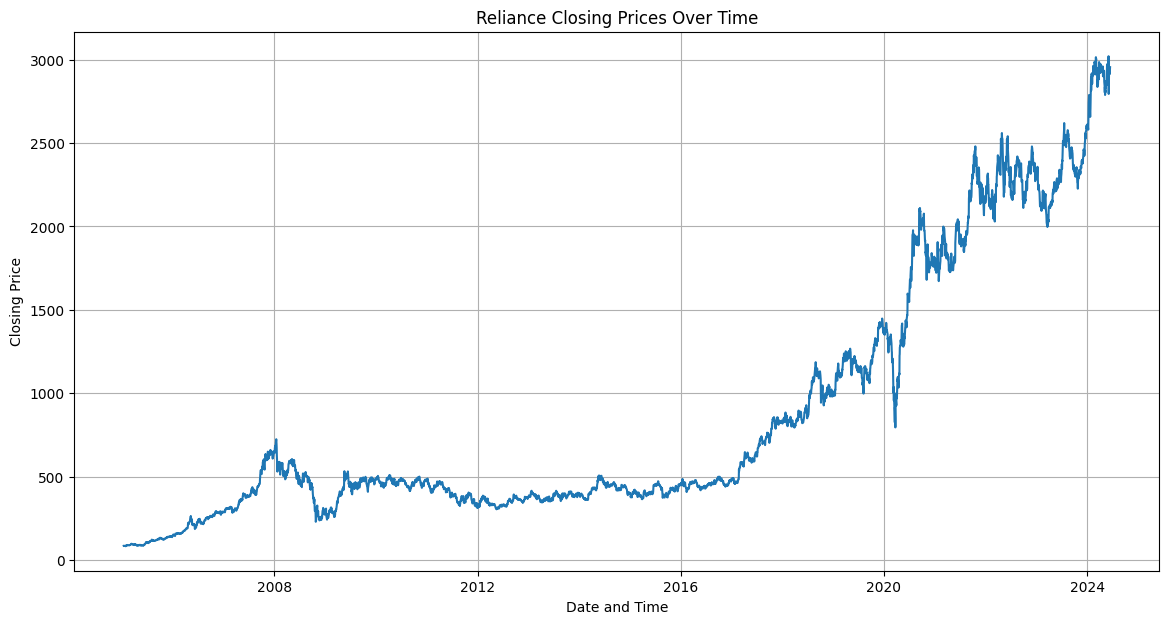

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(reliance_data['datetime'], reliance_data['close'])
plt.title('Reliance Closing Prices Over Time')
plt.xlabel('Date and Time')
plt.ylabel('Closing Price')
plt.grid(True)
plt.show()

C:\Users\Gulshankumar\AppData\Local\Temp\ipykernel_14372\2136213623.py:13: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(eod_data, bins=30)


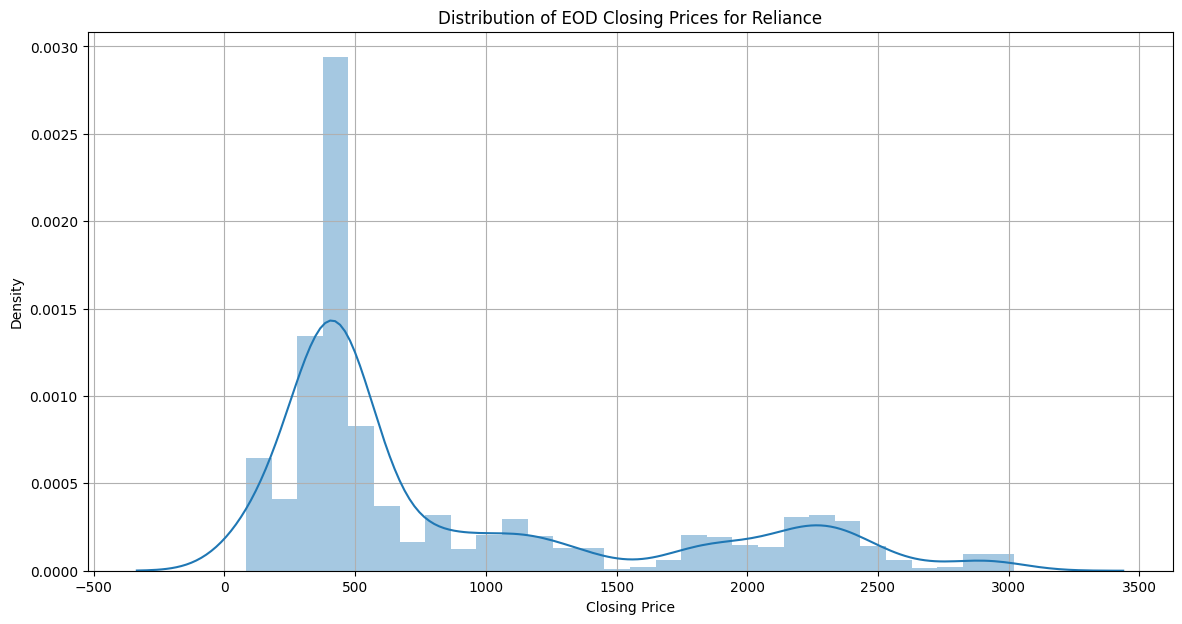

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'datetime' to datetime format
reliance_data['datetime'] = pd.to_datetime(reliance_data['datetime'])

# Extract EOD data
eod_data = reliance_data.groupby(reliance_data['datetime'].dt.date)['close'].last()

# Plot distribution
plt.figure(figsize=(14, 7))
sns.distplot(eod_data, bins=30)
plt.title('Distribution of EOD Closing Prices for Reliance')
plt.xlabel('Closing Price')
plt.grid(True)
plt.show()

In [15]:
import pandas as pd

# Convert 'datetime' to datetime format
reliance_data['datetime'] = pd.to_datetime(reliance_data['datetime'])

# Convert 'close' to a stationary series
reliance_data['close_stationary'] = reliance_data['close'].diff()

# Transform each value into the mean average of that day with a window size of 10
reliance_data['close_stationary_mean'] = reliance_data['close_stationary'].rolling(window=10).mean()

# Drop the rows with NaN values that were created by the rolling mean calculation
reliance_data = reliance_data.dropna()

# Normalize the data using Min-Max normalization
reliance_data['close_stationary_mean_normalized'] = (reliance_data['close_stationary_mean'] - reliance_data['close_stationary_mean'].min()) / (reliance_data['close_stationary_mean'].max() - reliance_data['close_stationary_mean'].min())

C:\Users\Gulshankumar\AppData\Local\Temp\ipykernel_14372\2372326478.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reliance_data['close_stationary_mean_normalized'] = (reliance_data['close_stationary_mean'] - reliance_data['close_stationary_mean'].min()) / (reliance_data['close_stationary_mean'].max() - reliance_data['close_stationary_mean'].min())


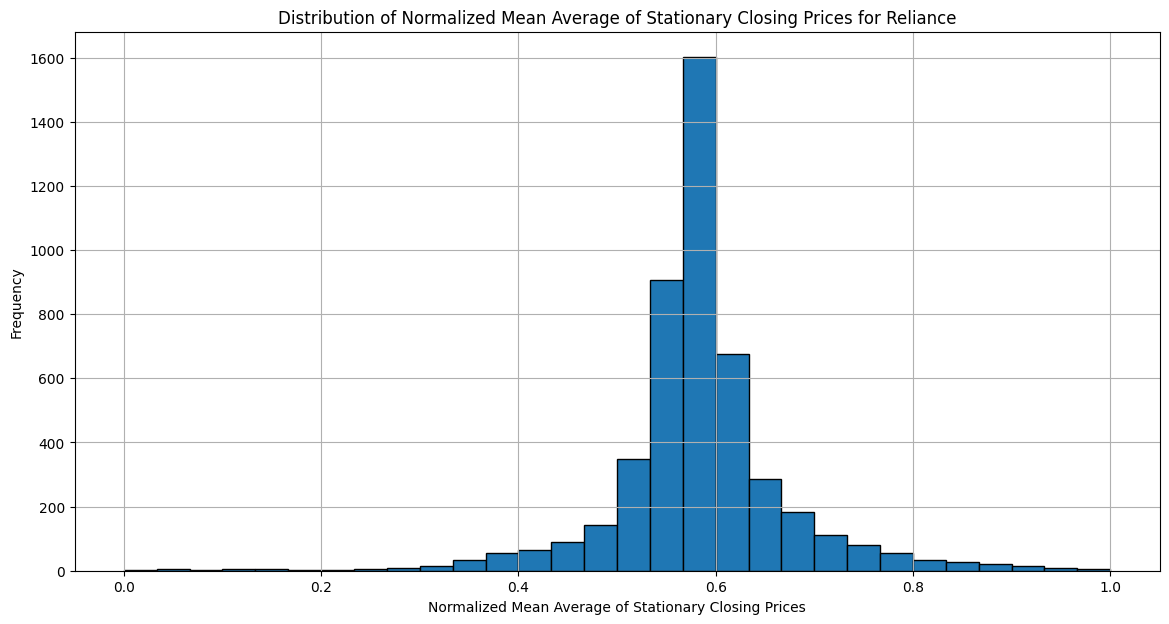

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
reliance_data['close_stationary_mean_normalized'].hist(bins=30, edgecolor='black')
plt.title('Distribution of Normalized Mean Average of Stationary Closing Prices for Reliance')
plt.xlabel('Normalized Mean Average of Stationary Closing Prices')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

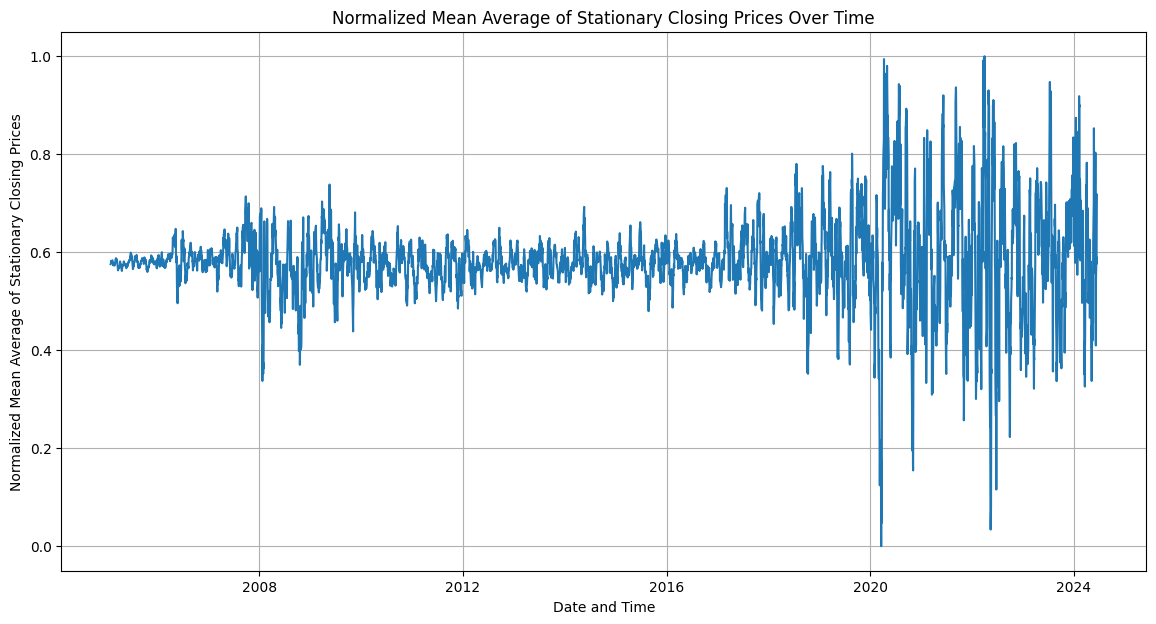

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(reliance_data['datetime'], reliance_data['close_stationary_mean_normalized'])
plt.title('Normalized Mean Average of Stationary Closing Prices Over Time')
plt.xlabel('Date and Time')
plt.ylabel('Normalized Mean Average of Stationary Closing Prices')
plt.grid(True)
plt.show()

In [18]:
import pandas as pd

# Create a new DataFrame
data = pd.DataFrame()

# Convert 'open', 'high', 'low', 'close', and 'volume' to stationary series
data['open_stationary'] = reliance_data['open'].diff()
data['high_stationary'] = reliance_data['high'].diff()
data['low_stationary'] = reliance_data['low'].diff()
data['close_stationary'] = reliance_data['close'].diff()
data['volume_stationary'] = reliance_data['volume'].diff()

# Normalize the data using Min-Max normalization
data = (data - data.min()) / (data.max() - data.min())

# Add the label
data['label'] = reliance_data['close_stationary_mean_normalized']

# Drop the rows with NaN values that were created by the diff calculation
data = data.dropna()

In [19]:
data

,open_stationary,high_stationary,low_stationary,close_stationary,volume_stationary,label
11,0.490404,0.441059,0.636558,0.547421,0.562401,0.577624
12,0.486341,0.441822,0.623584,0.547658,0.583752,0.581825
13,0.486966,0.435429,0.619899,0.539724,0.509077,0.580067
14,0.480404,0.433166,0.622791,0.546372,0.531658,0.582086
15,0.484243,0.436087,0.617980,0.541940,0.565761,0.580429
...,...,...,...,...,...,...
4796,0.707154,0.571719,0.878289,0.550414,0.544161,0.590178
4797,0.477217,0.309477,0.536517,0.472659,0.558698,0.576022
4798,0.420003,0.450106,0.622931,0.575411,0.553517,0.642866
4799,0.561003,0.411274,0.650440,0.552698,0.554491,0.696917


In [23]:
from sklearn.model_selection import train_test_split

# Split the data into a training set and a temporary set
train_data, temp_data = train_test_split(data, test_size=0.3, random_state=42)

# Split the temporary set into a validation set and a test set
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

In [25]:
def create_dataset(dataset, window_size):
    data_X, data_Y = [], []
    for i in range(len(dataset) - window_size):
        a = dataset[i:(i + window_size), :-1]  # Exclude the last column (label)
        data_X.append(a)
        data_Y.append(dataset[i + window_size, -1])  # Use the last column of the next day as the label
    return np.array(data_X), np.array(data_Y)

window_size = 8
train_X, train_Y = create_dataset(train_data.values, window_size)
val_X, val_Y = create_dataset(val_data.values, window_size)
test_X, test_Y = create_dataset(test_data.values, window_size)

# Reshape input to be [samples, time steps, features]
train_X = np.reshape(train_X, (train_X.shape[0], window_size, 5))
val_X = np.reshape(val_X, (val_X.shape[0], window_size, 5))
test_X = np.reshape(test_X, (test_X.shape[0], window_size, 5))